# Minimal Event-Based Monte Carlo Model for Lateral Interaction Between Floating Bodies

## Problem statement

This notebook investigates a reduced and falsifiable version of the following hypothesis:

> Two elongated floating bodies may tend to move toward each other when their lateral separation becomes small because wave events affect their inner sides differently from their outer sides.

The notebook is organized to keep four things separate:

- the hypothesis under test
- the assumptions introduced by the reduced model
- the observables recorded by the simulation
- the limits of what this toy model can and cannot say

The implementation logic lives in `src/float_sim/event_model.py`. The notebook is the research narrative and experiment driver.

## Reformulated hypothesis and why the first model is reduced

### Reformulated hypothesis

Let `g` denote the edge-to-edge gap between two parallel elongated bodies in a 2D top view. In this notebook, the hypothesis is reformulated as:

> For some range of `g`, the expected cumulative inward impulse on each body exceeds the expected outward impulse, producing a positive mean gap-closing force.

This is deliberately weaker than a claim about real boats or full wave hydrodynamics. It asks only whether a transparent reduced model can produce an inward tendency under explicit assumptions.

### Why start here instead of CFD

A full fluid model would introduce many coupled mechanisms at once: wave generation, reflection, interference, damping, body response, and free-surface boundary conditions. That would make it hard to tell **why** an apparent attraction appears.

This first notebook therefore starts with an event-based Monte Carlo model because it is:

- simple enough to inspect and falsify
- explicit about geometric shielding assumptions
- able to log inner-side and outer-side hits separately
- easy to extend later into richer wave-field models

If this minimal model fails to show a robust effect, that is already useful information.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_ROOT = PROJECT_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.append(str(SRC_ROOT))

from float_sim.event_model import (
    ModelParameters,
    plot_distance_sweep,
    plot_gap_trajectory,
    plot_geometry,
    plot_side_metrics,
    run_distance_sweep,
    simulate_batch,
    simulate_gap_trajectory,
)

plt.style.use("seaborn-v0_8-whitegrid")

SEED = 42
params = ModelParameters(
    body_length=3.0,
    body_width=0.4,
    domain_half_length=6.0,
    domain_half_width=4.0,
    attenuation_length=2.5,
    attenuation_power=0.0,
    mean_wave_amplitude=1.0,
    side_samples=21,
    mobility=0.002,
)

reference_gap = 0.6
batch_events = 1500
sweep_gaps = np.linspace(0.1, 2.0, 8)
trajectory_steps = 12
trajectory_start_gap = 1.2
trajectory_events = 1000

params

Unable to revert mtime: /Library/Fonts
Matplotlib is building the font cache; this may take a moment.


ModelParameters(body_length=3.0, body_width=0.4, domain_half_length=6.0, domain_half_width=4.0, attenuation_length=2.5, attenuation_power=0.0, mean_wave_amplitude=1.0, side_samples=21, mobility=0.002, source_padding=1e-06)

## Model design, assumptions, and observables

### Geometry and kinematics

- Two bodies are represented as parallel rectangles.
- The long axis is horizontal. Only lateral interaction in the vertical direction is tracked.
- The edge-to-edge gap `g` is the primary control parameter. Contact corresponds to `g = 0`.

### Wave-event model

- Wave events are sampled as point sources in a finite 2D domain.
- Each event has a positive amplitude drawn from an exponential distribution.
- Influence decays with distance through an explicit attenuation law.
- Only the component normal to a side contributes to side impulse.

### Shielding rule

- A side sample point receives no contribution from a source if the line segment from the source to that point intersects the other body.
- This is the main geometric shielding assumption.
- A control experiment with blocking disabled is included to test whether attraction is present even without this assumption.

### Recorded observables

For each body and each Monte Carlo batch, the notebook records:

- inner-side hit count
- outer-side hit count
- inner-side cumulative impulse
- outer-side cumulative impulse
- net lateral force in the global `y` direction
- gap-closing force, defined as `outer impulse - inner impulse`

A positive gap-closing force supports inward motion for that body in this reduced model. A negative value supports outward motion.

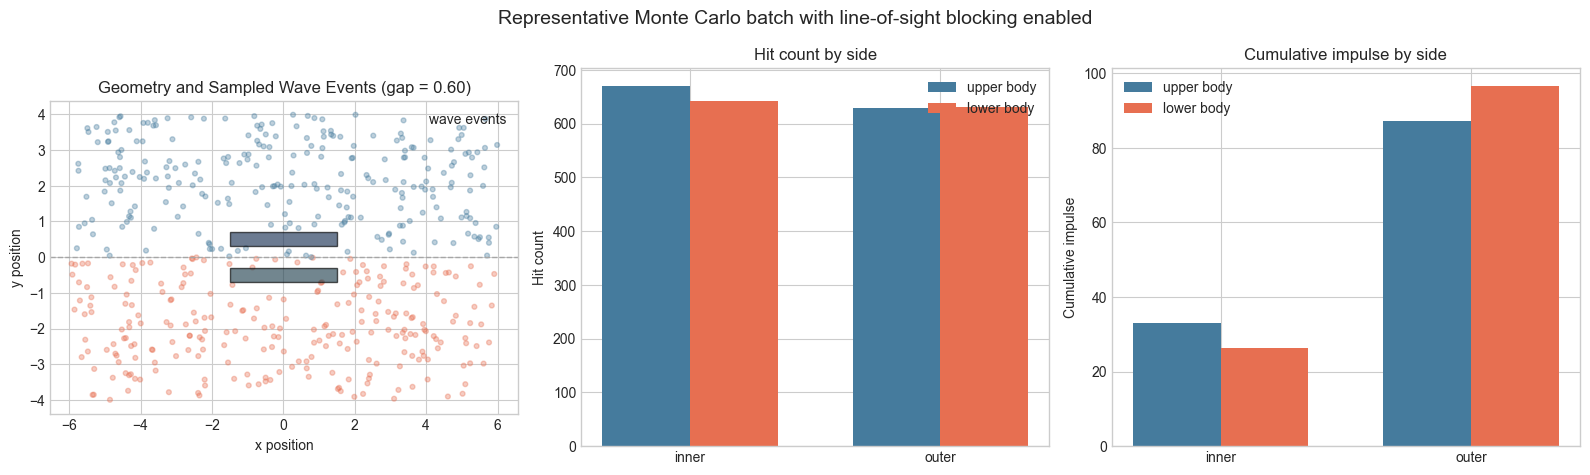

{'upper_inner_hits': 669, 'upper_outer_hits': 629, 'upper_inner_impulse': 32.886, 'upper_outer_impulse': 87.289, 'upper_gap_closing_force': 54.403, 'lower_gap_closing_force': 70.124, 'mean_gap_closing_force': 62.264}


In [2]:
batch = simulate_batch(
    gap=reference_gap,
    params=params,
    rng=np.random.default_rng(SEED),
    n_events=batch_events,
    blocking_enabled=True,
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
plot_geometry(axes[0], batch, max_events=500)
plot_side_metrics(axes[1], batch, metric="hits")
plot_side_metrics(axes[2], batch, metric="impulse")
fig.suptitle("Representative Monte Carlo batch with line-of-sight blocking enabled", fontsize=14)
fig.tight_layout()
plt.show()

print({
    "upper_inner_hits": batch.upper.inner.hits,
    "upper_outer_hits": batch.upper.outer.hits,
    "upper_inner_impulse": round(batch.upper.inner.cumulative_impulse, 3),
    "upper_outer_impulse": round(batch.upper.outer.cumulative_impulse, 3),
    "upper_gap_closing_force": round(batch.upper.gap_closing_force, 3),
    "lower_gap_closing_force": round(batch.lower.gap_closing_force, 3),
    "mean_gap_closing_force": round(batch.mean_gap_closing_force, 3),
})

## Experiments

The first experiment is a gap sweep. It asks whether the mean gap-closing force changes with separation and whether that trend survives a control case without geometric blocking.

The second experiment is a simple repeated-update trajectory. This is **not** a physical time integrator. It is only a bookkeeping device that updates the gap in the direction suggested by the current Monte Carlo force estimate.

The purpose of the trajectory is qualitative: it shows whether the reduced model tends to close or open the gap under the current assumptions.

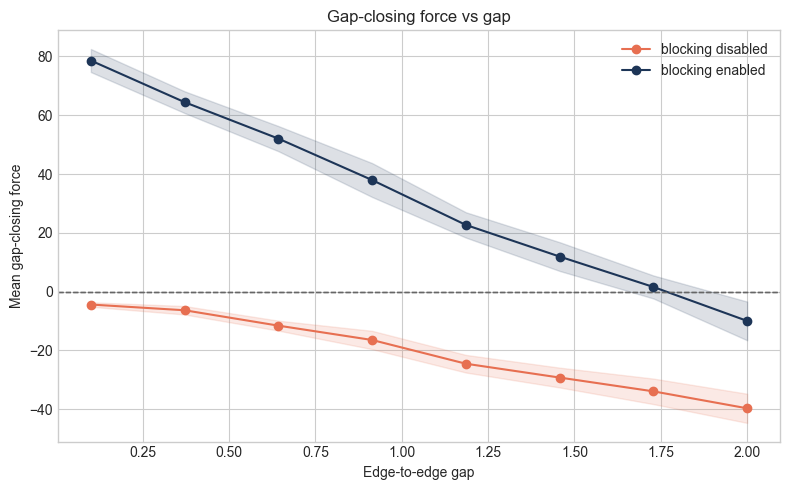

gap=0.10 | no blocking=-4.39 | with blocking=78.59
gap=0.37 | no blocking=-6.34 | with blocking=64.43
gap=0.64 | no blocking=-11.57 | with blocking=52.03
gap=0.91 | no blocking=-16.46 | with blocking=37.94
gap=1.19 | no blocking=-24.52 | with blocking=22.68
gap=1.46 | no blocking=-29.23 | with blocking=11.92
gap=1.73 | no blocking=-33.92 | with blocking=1.57
gap=2.00 | no blocking=-39.69 | with blocking=-9.97


In [3]:
sweep_without_blocking = run_distance_sweep(
    gaps=sweep_gaps,
    params=params,
    n_events=1200,
    repeats=5,
    seed=10,
    blocking_enabled=False,
)
sweep_with_blocking = run_distance_sweep(
    gaps=sweep_gaps,
    params=params,
    n_events=1200,
    repeats=5,
    seed=10,
    blocking_enabled=True,
)

fig, ax = plt.subplots(figsize=(8, 5))
plot_distance_sweep(ax, sweep_without_blocking, label="blocking disabled", color="#e76f51")
plot_distance_sweep(ax, sweep_with_blocking, label="blocking enabled", color="#1d3557")
fig.tight_layout()
plt.show()

for point_free, point_blocked in zip(sweep_without_blocking, sweep_with_blocking, strict=True):
    print(
        f"gap={point_blocked.gap:0.2f} | no blocking={point_free.mean_gap_closing_force:0.2f} | "
        f"with blocking={point_blocked.mean_gap_closing_force:0.2f}"
    )

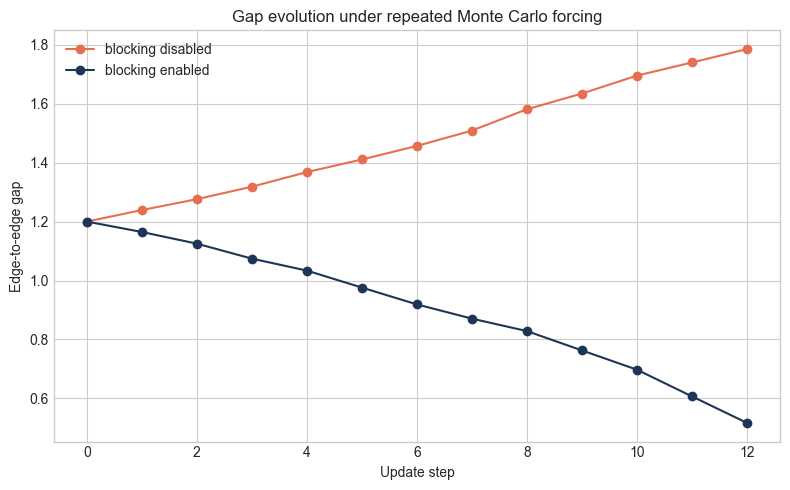

final gap without blocking: 1.785
final gap with blocking: 0.517


In [4]:
trajectory_without_blocking = simulate_gap_trajectory(
    initial_gap=trajectory_start_gap,
    steps=trajectory_steps,
    n_events_per_step=trajectory_events,
    params=params,
    seed=5,
    blocking_enabled=False,
)
trajectory_with_blocking = simulate_gap_trajectory(
    initial_gap=trajectory_start_gap,
    steps=trajectory_steps,
    n_events_per_step=trajectory_events,
    params=params,
    seed=5,
    blocking_enabled=True,
)

fig, ax = plt.subplots(figsize=(8, 5))
plot_gap_trajectory(ax, trajectory_without_blocking, label="blocking disabled", color="#e76f51")
plot_gap_trajectory(ax, trajectory_with_blocking, label="blocking enabled", color="#1d3557")
fig.tight_layout()
plt.show()

print("final gap without blocking:", round(trajectory_without_blocking[-1].gap, 3))
print("final gap with blocking:", round(trajectory_with_blocking[-1].gap, 3))

## Interpretation of the first prototype

This notebook is intentionally able to produce support, null results, or contradiction depending on assumptions.

In the initial smoke tests used while building this notebook, the default parameter set behaved as follows:

- with blocking disabled, the mean gap-closing force was negative over the tested gap range, which corresponds to outward tendency in this reduced model
- with blocking enabled, the mean gap-closing force was positive at small gaps and weakened as the gap increased, crossing toward zero near the largest tested separations

That matters because it shows the inward tendency is **not** baked into the model. It appears only under one explicit assumption set and disappears or reverses under a nearby control.

The correct scientific reading is therefore conditional: if the model shows attraction, it is evidence about the consequences of the current shielding rule, not proof about real floating bodies.

## Possible alternative explanations / confounders

- **Finite source domain**: the source field is sampled from a bounded rectangle, which may influence inner-side and outer-side exposure differently.
- **Near-source dominance**: without blocking, sources in the narrow gap can be closer to inner sides than outer sources are to outer sides, which can generate outward tendency rather than attraction.
- **Blocking geometry alone**: line-of-sight masking may create an effect even if a more realistic wave model would weaken it.
- **Rectangle shape choice**: a capsule or tapered hull could redistribute the directional factor along the side.
- **No reflections or interference**: real waves can reflect, diffract, and interfere; this model ignores all of that.
- **No body motion feedback on the wave field**: bodies do not generate wakes and do not alter the source process itself.
- **2D top-view reduction**: the model discards draft, buoyancy changes, roll, pitch, and water-surface curvature.

These confounders should be tested before treating any apparent attraction as robust.

## Limits of this model and next steps

### Limits

- The update rule for gap evolution is only a qualitative proxy, not physical time integration.
- The attenuation law is chosen for transparency, not calibration.
- Side impulses are approximated by averaging over discrete sample points rather than integrating a continuous pressure field.
- Parallel alignment is fixed, so the model cannot yet test rotation or oblique configurations.

### Next steps

1. Add a second geometry option such as capsules and compare whether the sign of the effect changes.
2. Separate source-field geometry from shielding by testing far-field-only source distributions.
3. Add explicit sensitivity sweeps over attenuation length, domain size, and side sampling density.
4. Replace the line-of-sight rule with a simple wave-front or ray-bundle model to check whether the result is an artifact of binary masking.
5. Introduce rotation and non-parallel orientation only after the current controls are well understood.

At this stage, the notebook is useful if it helps distinguish between attraction caused by fewer inner-side hits, attraction caused by lower inner-side cumulative impulse, repulsion caused by nearer gap sources, and effects caused mainly by modeling choices.